In [78]:
import os
import sys
from turtledemo.chaos import plot

from jupyterlab_server.process import which
from scipy.cluster.vq import whiten
from scipy.stats import alpha

project_root = os.path.abspath('..')

if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.sentiment_analyzer import get_sentiment


In [2]:
df = pd.read_csv(filepath_or_buffer="../data/processed/imdb_clean.csv", sep=",")

In [3]:
df

,Title,Year,Duration (min),Genre,Rating,Metascore,Director,Cast,Votes,Description,Review Count,Review Title,Review,metascore_missing,reviews_tokenizadas
0,The Idea of You,2023.0,115.0,"Comedy, Drama, Romance",6.4,67.0,Michael Showalter,"Anne Hathaway, Nicholas Galitzine, Ella Rubin,...","28,744","Solène, a 40-year-old single mom, begins an un...",166,Hypocrisy as an idea,"This film, as well as the reaction to it, is a...",0,film well reaction wonderful example modern hy...
1,Kingdom of the Planet of the Apes,2023.0,145.0,"Action, Adventure, Sci-Fi",7.3,66.0,Wes Ball,"Owen Teague, Freya Allan, Kevin Durand, Peter ...","22,248","Many years after the reign of Caesar, a young ...",183,A phenomenal start to another trilogy!,"I'm a big fan of all the planet of the apes, a...",0,big fan planet ape nailed one usually start mi...
2,Unfrosted,2023.0,97.0,"Biography, Comedy, History",5.5,42.0,Jerry Seinfeld,"Isaac Bae, Jerry Seinfeld, Chris Rickett, Rach...","18,401","In 1963 Michigan, business rivals Kellogg's an...",333,not funny,Pretty much the worst criticism you can lay on...,0,pretty much worst criticism lay comedian true ...
3,The Fall Guy,2023.0,126.0,"Action, Comedy, Drama",7.3,73.0,David Leitch,"Ryan Gosling, Emily Blunt, Aaron Taylor-Johnso...","38,953",A down-and-out stuntman must find the missing ...,384,Everything you needed and more!,Just got out of the Austin premier at SXSW and...,0,got austin premier sxsw whole theatre went nut...
4,Challengers,2023.0,131.0,"Drama, Romance, Sport",7.7,82.0,Luca Guadagnino,"Zendaya, Mike Faist, Josh O'Connor, Darnell Ap...","32,517","Tashi, a former tennis prodigy turned coach, t...",194,"Watch ""Match Point"" instead",This is a tough one. I liked the concept and t...,0,tough one liked concept overall story however ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9331,The Greatest Show on Earth,2020.0,152.0,"Drama, Family, Romance",6.5,76.0,Cecil B. DeMille,"James Stewart, Charlton Heston, Betty Hutton, ...","16,078","The dramatic lives of trapeze artists, a clown...",128,"Hey, doesn't anyone remember Last Emperor?",It constantly amazes me that people carp that ...,0,constantly amazes people carp best picture tho...
9332,Berserk: Ougon Jidai-hen I - Haou no Tamago,2020.0,76.0,"Animation, Action, Adventure",7.5,58.0,Toshiyuki Kubooka,"Hiroaki Iwanaga, Carrie Keranen, Takahiro Saku...","14,300",A lone sellsword named Guts gets recruited int...,12,Masterfully directed climatic epic saga,Few stories can capture your mind and soul in ...,1,story capture mind soul visceral way beginning...
9333,Is-slottet,2020.0,78.0,"Mystery, Drama",6.5,58.0,Per Blom,"Line Storesund, Hilde Nyeggen Martinsen, Meret...",740,A couple of twelve-year-old Norwegian girls st...,4,Beautiful Film,"This film might not be to everyone's taste, it...",1,film might everyone taste slow moving like goo...
9334,Loving Pablo,2020.0,123.0,"Biography, Crime, Drama",6.4,42.0,Fernando León de Aranoa,"Javier Bardem, Penélope Cruz, Peter Sarsgaard,...","22,447",A journalist strikes up a romantic relationshi...,84,That film should be in Spanish,Why anyone (the director?) made Spanish actors...,0,anyone director made spanish actor speak bad e...


In [4]:
df['sentiment'] = df['reviews_tokenizadas'].apply(get_sentiment)

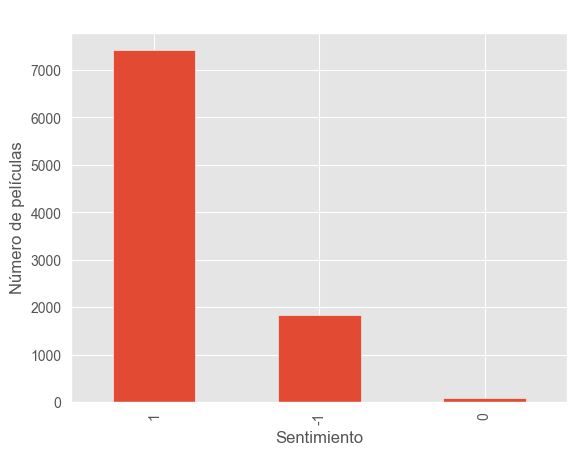

In [5]:
df['sentiment'].value_counts().plot(kind='bar')
plt.xlabel("Sentimiento")
plt.ylabel("Número de películas")
plt.title("Distribuición del sentimiento de las reseñas")
plt.show()
#plt.savefig('../figures/distribucion_sentimiento_por_reseñas.png', dpi=300, bbox_inches='tight')

In [10]:
df["sentiment"].value_counts()

sentiment
 1    7414
-1    1831
 0      91
Name: count, dtype: int64

El 99.27% de las reseñas son representadas como positivas, mientras el resto, 0.72, representa las reseñas neutrales. El dataset obtenido tiene su origen de IMDB, donde los usuarios tienden a realizar reseñas de aquellas películas que le han gustado, esto se puede confirmar realizando mediante el análisis de sentimiento el cual diferencia entre opiniones positivas,
 negativas o neutrales.

In [11]:
df["sentiment"].value_counts(normalize=True) * 100

sentiment
 1    79.413025
-1    19.612254
 0     0.974722
Name: proportion, dtype: float64

Mediante la agrupación que nos permite realizar la librería de pandas agrupamos las películas por sentimiento y calculamos para aquellas el rating medio en cada grupo. Y, por tanto, podemos observar que aquellas valoraciones que disponen de una puntuación superior son las que tienen reseñas positivas (sentiment = 1) mientras que las reseñas que disponen de un puntuación de neutralidad tienden a ser valores del rating en torno al 5, lo cual concuerda con nuestro análisis de sentimiento realizado.

In [12]:
df.groupby('sentiment')['Rating'].mean()

sentiment
-1    6.069143
 0    6.064835
 1    6.538791
Name: Rating, dtype: float64

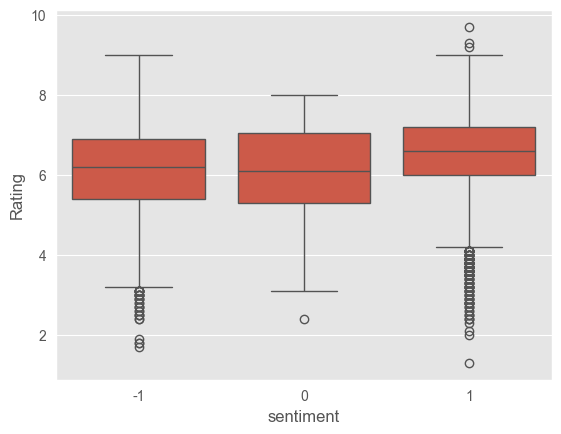

In [13]:
sns.boxplot(x="sentiment", y="Rating", data=df)
#plt.savefig('../figures/sentimiento_por_rating.png', dpi=300, bbox_inches='tight')

In [14]:
df['Director'].value_counts()

Director
Steven Spielberg     33
Clint Eastwood       32
Ridley Scott         27
Martin Scorsese      24
Steven Soderbergh    24
                     ..
Steffen Haars         1
Pippa Ehrlich         1
Matt Smukler          1
Jude Bauman           1
Claude Lelouch        1
Name: count, Length: 4272, dtype: int64

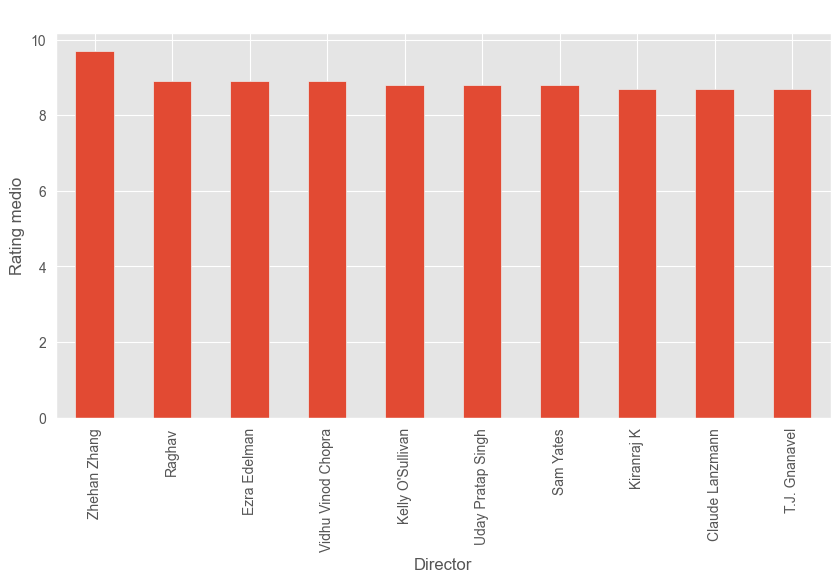

In [64]:
director_sort_best_rating = df.groupby('Director')['Rating'].mean().sort_values(ascending=False).head(10)
director_sort_best_rating.plot(kind="bar", figsize=(10, 5), title="Directores con mejor Rating")
plt.xlabel("Director")
plt.ylabel("Rating medio")
plt.show()


In [50]:
top_directors = df.groupby('Director').agg(
    mean_rating=("Rating", "mean"),
    sum_movies=("Rating", "count")
)
top_directors = top_directors[top_directors['sum_movies'] >= 5]
top_directors = top_directors.sort_values('mean_rating', ascending=False).head(10)

,mean_rating,sum_movies
Director,,
Sergio Leone,8.216667,6
Akira Kurosawa,8.211111,9
Christopher Nolan,8.166667,12
Stanley Kubrick,8.090909,11
Quentin Tarantino,8.081818,11
Ingmar Bergman,8.080000,5
Andrei Tarkovsky,7.983333,6
Hayao Miyazaki,7.972727,11
Billy Wilder,7.963636,11


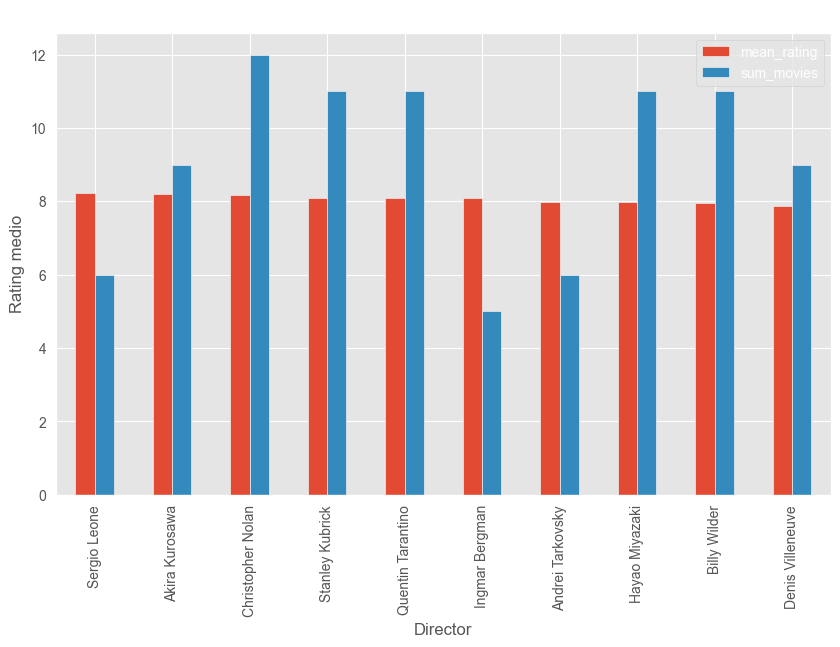

In [17]:
top_directors.plot(kind='bar', figsize=(10, 6), title="Rating medio por Director (Top 10)")
plt.xlabel("Director")
plt.ylabel("Rating medio")
plt.show()
#plt.savefig("../figures/rating_medio_por_director.png", dpi=300, bbox_inches='tight')

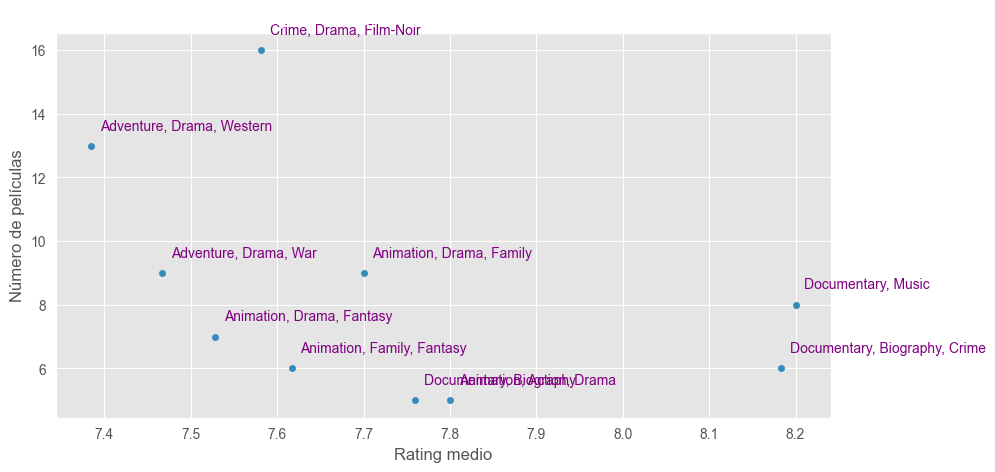

In [89]:
top_genres = df.groupby('Genre', as_index=False).agg(
    mean_rating=('Rating', 'mean'),
    sum_movies=('Rating', 'count')
)
top_genres = top_genres[top_genres['sum_movies'] >= 5]
top_genres = top_genres.sort_values('mean_rating', ascending=False).head(10)


ax = top_genres.plot(kind="scatter",
                     x="mean_rating",
                     y="sum_movies",
                     figsize=(10, 5))

for _, row in top_genres.iterrows():
    ax.text(row["mean_rating"] + 0.01,
            row["sum_movies"] + 0.5,
            row['Genre'],
            color="purple")


ax.set_title("Rating medio vs número de películas por género")
ax.set_xlabel("Rating medio")
ax.set_ylabel("Número de películas")

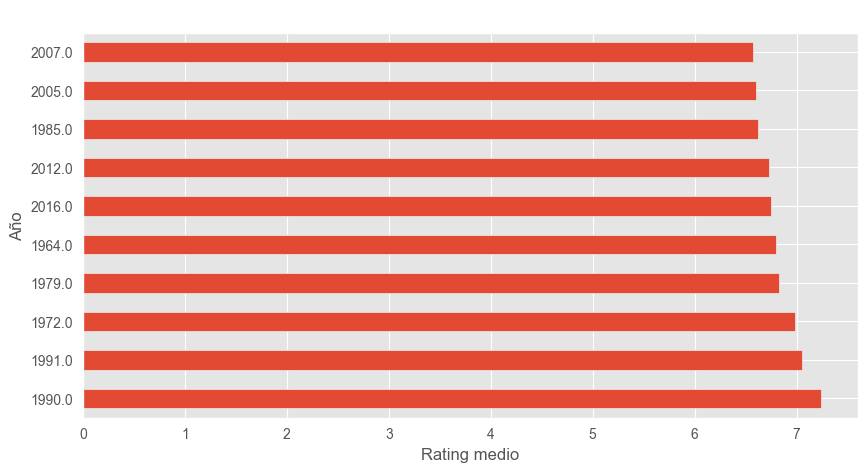

In [43]:
rating_by_year = df.groupby('Year')['Rating'].mean().sort_values(ascending=False).head(10)

rating_by_year.plot(kind="barh", figsize=(10, 5), title="Mejores años por rating medio")
plt.ylabel("Año")
plt.xlabel("Rating medio")
plt.show()

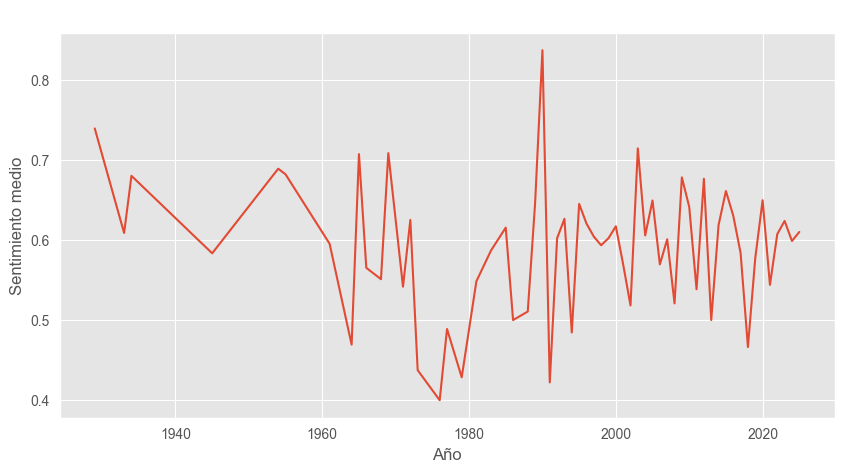

In [32]:
evolution_sentiment_by_year = df.groupby('Year')["sentiment"].mean()

evolution_sentiment_by_year.plot(figsize=(10, 5))
plt.xlabel("Año")
plt.ylabel("Sentimiento medio")
plt.title("Evolución del sentimiento medio por año")
plt.show()

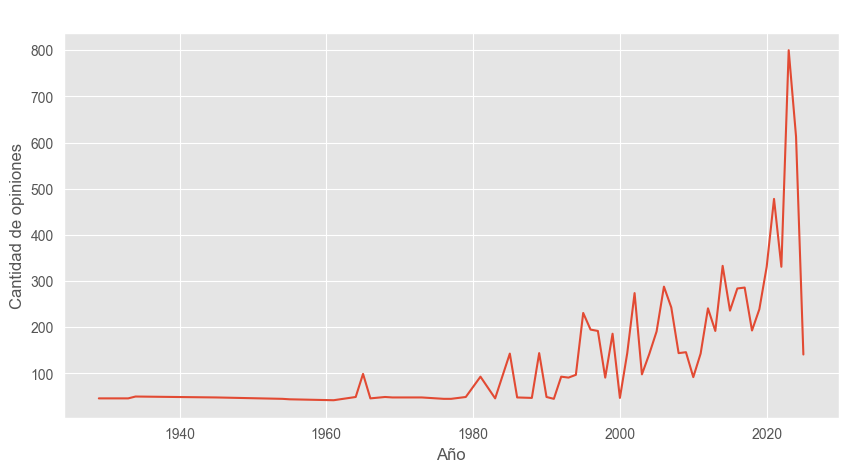

In [37]:
top_year_by_sentiment = df.groupby('Year')['sentiment'].count()

top_year_by_sentiment.plot(kind="line", figsize=(10, 5), title="Evolución de las opiniones publicadas por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de opiniones")
plt.show()

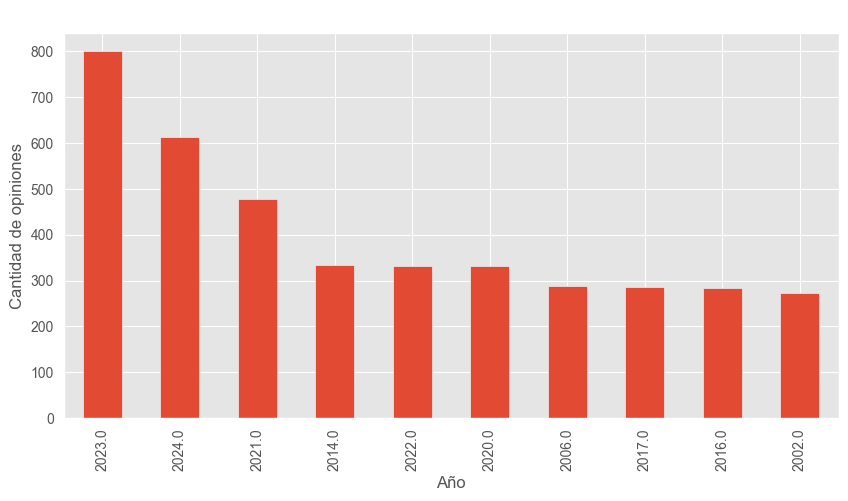

In [40]:
top_year_by_sentiment = df.groupby('Year')['sentiment'].count().sort_values(ascending=False).head(10)

top_year_by_sentiment.plot(kind="bar", figsize=(10, 5), title="Evolución de las opiniones publicadas por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de opiniones")
plt.show()

In [48]:
top_genres_positives = df.groupby('Genre').agg(
    sum_sentiment_positives=('sentiment', lambda x: (x == 1).sum()),
    sum_movies=('sentiment', 'count')
)

top_genres_positives = top_genres_positives.sort_values('sum_movies', ascending=False)
top_genres_positives

,sum_sentiment_positives,sum_movies
Genre,,
Drama,350,442
"Comedy, Drama, Romance",322,358
"Drama, Romance",301,346
"Comedy, Drama",243,273
Comedy,230,270
...,...,...
"Comedy, Music, Musical",1,1
"Comedy, Music, Mystery",1,1
"Drama, Fantasy, War",1,1
